In [7]:
import numpy as np
from scipy.integrate import solve_ivp

step = 100


x = np.linspace(0, 1, step)
x_step = 1/step


def d2(u):
    u = np.concatenate([np.array(u[:1]), u,np.array(u[-1:])])
    return (u[2:] + u[:-2] + -2*u[1:-1])/x_step ** 2

def dxdxu(t, u):
    return d2(u)

def udxdxu(t, u):
    return u*d2(u)

def uudxdxu(t, u): 
    return u**2*d2(u)

def uuudxdxu(t, u): 
    return u**3*d2(u)

y0 = np.exp(-100 * (x - 0.5) ** 2)

y_0 = solve_ivp(dxdxu, [0, 0.005], y0, t_eval = [0, 0.001, 0.002, 0.003, 0.004, 0.005])
y_1 = solve_ivp(udxdxu, [0, 0.005], y0, t_eval = [0, 0.001, 0.002, 0.003, 0.004, 0.005])
y_2 = solve_ivp(uudxdxu, [0, 0.005], y0, t_eval = [0, 0.001, 0.002, 0.003, 0.004, 0.005])
y_3 = solve_ivp(uuudxdxu, [0, 0.005], y0, t_eval = [0, 0.001, 0.002, 0.003, 0.004, 0.005])

/home/c_earth/python_virtualenv/TNPDE/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


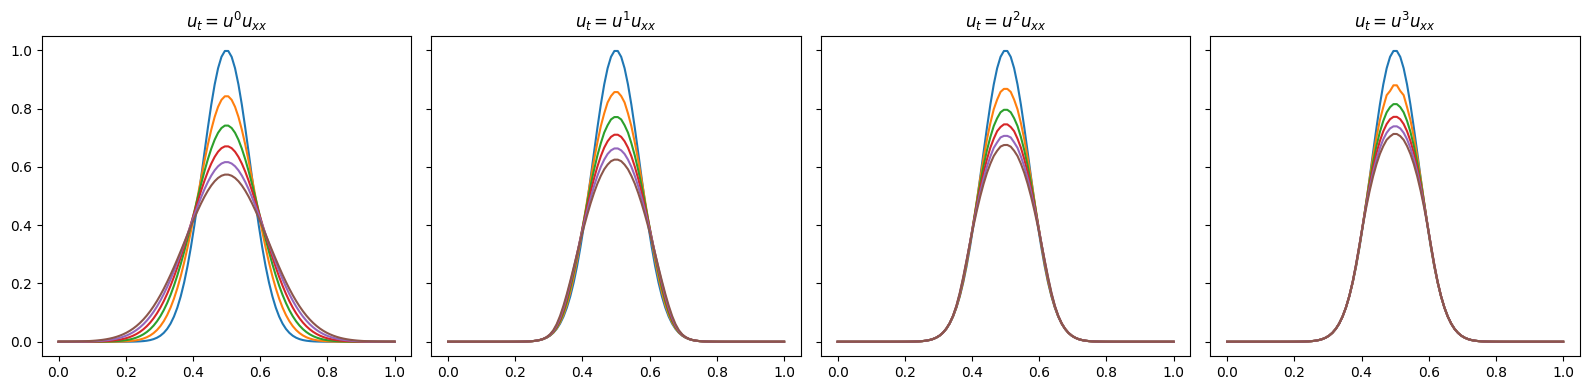

In [8]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, sharey = True, sharex = True, figsize = (16, 4))
for i, (ax, y) in enumerate(zip(axs.ravel(), [y_0, y_1, y_2, y_3])):
    ax.plot(x, y.y)
    ax.set_title(rf'$u_t=u^{i}u_{{xx}}$')
fig.tight_layout()
fig.show()

In [3]:
from utils.pde import PDE

pde_dxdxu_txt = 'D[2, 0, 0]'
pde_udxdxu_txt = 'u*D[2, 0, 0]'
pde_uudxdxu_txt = 'u*u*D[2, 0, 0]'
pde_uuudxdxu_txt = 'u*u*u*D[2, 0, 0]'

pde_dxdxu = PDE(pde_dxdxu_txt, equal_time_derivative = True)
pde_udxdxu = PDE(pde_udxdxu_txt, equal_time_derivative = True)
pde_uudxdxu = PDE(pde_uudxdxu_txt, equal_time_derivative = True)
pde_uuudxdxu = PDE(pde_uuudxdxu_txt, equal_time_derivative = True)

In [4]:
from utils.triangulation import Triangulation
from utils.finite_element import LagrangeBasis, FiniteElement
from utils.tensor_network import TensorUnit, TensorNetwork
from utils.solver import DMRG

triangulation = Triangulation(np.linspace(0, 1, 10))
basis = LagrangeBasis(1, 3)

fe = FiniteElement(triangulation, basis)
fe.set_con_bc_operators(1)
fe.calculate_higher_domain_derivatives(2)

tn = TensorNetwork(basis.rank, triangulation.neighbors, fe.domain_derivatives_list, basis.tp_reduce)
tn.set_u_shape(tuple())
tn.set_h_tensor_units([])

bond_order = 1
delta = 0.001

y0 = lambda x: np.exp(-100*(x-0.5)**2)
rep = fe.fun2rep(y0)
rep = np.broadcast_to(rep[..., None, None], rep.shape + (bond_order,) * (basis.d + 1))
states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)
tn.set_states(states, bond_order)
tn.set_bcs(fe.con_bc_operators, fe.env_bc_operators, 1)
tn.set_solver(DMRG())

all_reps = [[states.tensor[..., 0, 0].copy()], [states.tensor[..., 0, 0].copy()], [states.tensor[..., 0, 0].copy()], [states.tensor[..., 0, 0].copy()]]
for reps, pde in zip(all_reps, [pde_dxdxu, pde_udxdxu, pde_uudxdxu, pde_uuudxdxu]):
    for i in range(5):
        print(i)
        pde_operators, pde_power =  tn.get_operators_from_pde(pde.pde, delta, states.copy())
        tn.set_states(states, bond_order)
        tn.set_bcs(fe.con_bc_operators, fe.env_bc_operators, 1)
        tn.set_solver(DMRG())
        tn.set_operators(pde_operators, pde_power)
        states = tn.solve(rounds = 5, alpha = 1, env = False)
        reps.append(states.tensor[..., 0, 0].copy())
    states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4


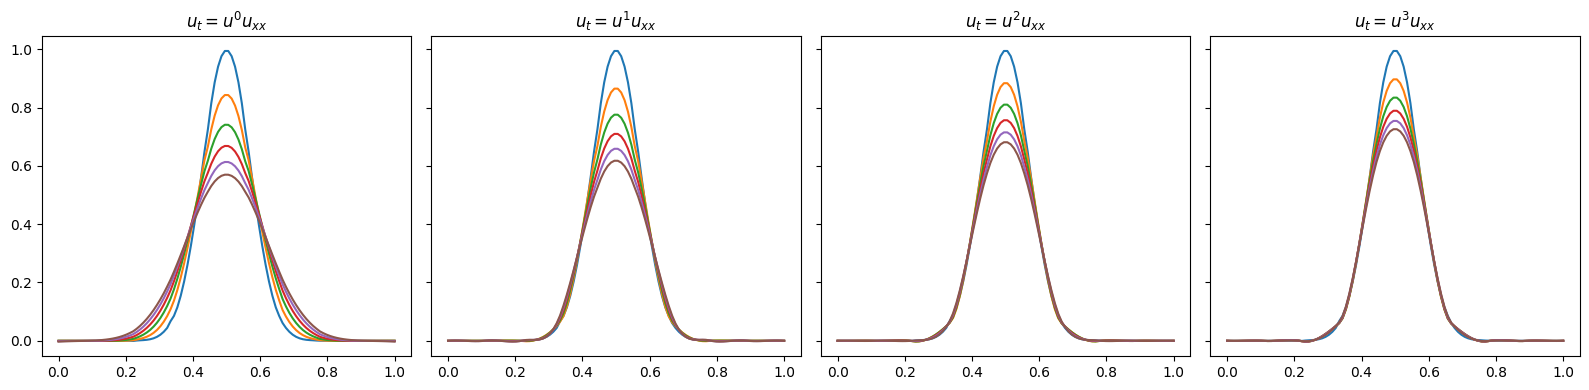

In [9]:
x = np.linspace(0, 1, 100)

fig, axs = plt.subplots(1, 4, sharey = True, sharex = True, figsize = (16, 4))
for i, (ax, reps) in enumerate(zip(axs.ravel(), all_reps)):
    for rep in reps:
        ax.plot(x, fe.rep2fun(rep)(x))
    ax.set_title(rf'$u_t=u^{i}u_{{xx}}$')
fig.tight_layout()
fig.show()

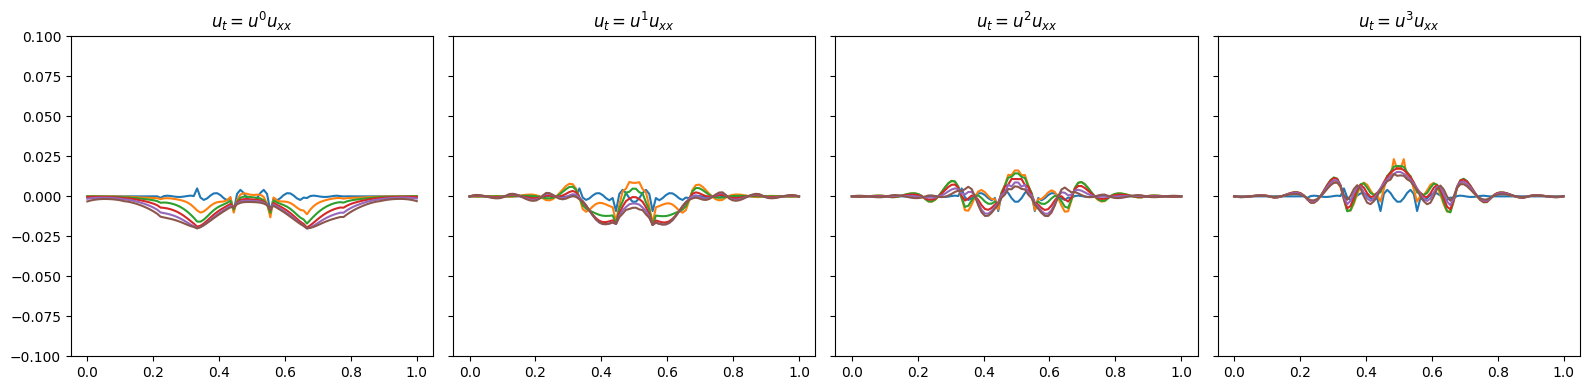

In [11]:
fig, axs = plt.subplots(1, 4, sharey = True, sharex = True, figsize = (16, 4))
for i, (ax, reps, y) in enumerate(zip(axs.ravel(), all_reps, [y_0, y_1, y_2, y_3])):
    for j, rep in enumerate(reps):
        dy = fe.rep2fun(rep)(x) - y.y[..., j]
        ax.plot(x, dy)
    ax.set_title(rf'$u_t=u^{i}u_{{xx}}$')
    ax.set_ylim(-0.1, 0.1)
fig.tight_layout()
fig.show()